In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


✅ git+https://github.com/openai/CLIP.git
This installs the CLIP model code directly from OpenAI’s GitHub repo.

The git+https part tells pip to clone the repository and install it as a package.

This gives us access to:

clip.load(...) to load the pretrained model

clip.tokenize(...) for converting text to tokens

and other CLIP utilities



In [2]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-2m08drvo
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-2m08drvo
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:

import torch
import clip
from PIL import Image

# Load the model (ViT-B/32) and preprocessing transforms
model, preprocess = clip.load("ViT-B/32")

# Load an image:1,2,3
image = preprocess(Image.open("/content/download-1.jpg")).unsqueeze(0)  # shape [1, 3, 224, 224]

# Define class labels as natural language prompts
texts = clip.tokenize(["a photo of a dog", "a photo of a cat", "a photo of a bird"])

# Move to device
device = "cuda" if torch.cuda.is_available() else "cpu"
image, texts = image.to(device), texts.to(device)
model = model.to(device)

# Compute embeddings
with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(texts)

    # Normalize for cosine similarity
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Compute similarity scores
    similarity = (image_features @ text_features.T).squeeze()

# Print results
for label, score in zip(["dog", "cat", "bird"], similarity):
    print(f"{label}: {score.item():.4f}")

100%|███████████████████████████████████████| 338M/338M [00:11<00:00, 31.6MiB/s]


dog: 0.2825
cat: 0.2144
bird: 0.1963


🧠🔍 Step 2: Visualize CLIP Text Embeddings with t-SNE
This step helps to understand how CLIP semantically arranges different concepts in its high-dimensional space.

We'll:

Define a diverse set of text prompts.

Encode them using CLIP.

Reduce the 512D embeddings to 2D using t-SNE.

Plot the results.



📦 Code Cell: Install & Import

1. !pip install
The ! tells Colab to run a shell command (i.e., a command-line instruction).

pip install is Python’s package installer. It fetches and installs external libraries.

✅ ftfy, regex, and tqdm
These are dependencies used by CLIP or by your notebook.

Package	Purpose
ftfy (fixes text for you)	Fixes broken unicode characters in text — helps normalize inputs before tokenization (e.g., for emojis, accents, etc.).
regex	A more powerful and flexible version of Python's built-in regular expressions (re) — often needed by tokenizer tools.
tqdm	A progress bar library — useful when running loops over large data, e.g., encoding many images or prompts.


In [4]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

import torch
import clip
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np


  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-k2gmk3r0
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-k2gmk3r0
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done


🧠 model, preprocess = clip.load("ViT-B/32", device=device)
This line loads the CLIP model and its preprocessing pipeline:

"ViT-B/32": This specifies which CLIP model to load.

It stands for a Vision Transformer with base size (B) and a patch size of 32.

device=device: This ensures the model is moved to the correct device (CPU or GPU).

What it returns:

model: the pretrained CLIP model (with both image and text encoders)

preprocess: a torchvision-style preprocessing pipeline to convert images into the input format expected by the model

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

prompts = [
    "a dog", "a cat", "a fish", "a horse",
    "a car", "an airplane", "a bicycle",
    "a teacher", "a doctor", "a robot",
    "a painting", "a sculpture", "a photo",
    "a happy person", "a sad person", "a dancing person",
    "sunset", "mountain", "city", "forest"
]


🔍 What is t-SNE?
t-SNE (t-distributed Stochastic Neighbor Embedding) is a dimensionality reduction technique often used to visualize high-dimensional data in 2D or 3D.

In this case:

text_embeddings are 512-dimensional vectors (output by CLIP).

We want to reduce them to 2D to plot and visualize them.



In [6]:
with torch.no_grad():
    text_tokens = clip.tokenize(prompts).to(device)
    text_embeddings = model.encode_text(text_tokens).cpu().numpy()

# t-SNE for 2D visualization
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
text_embeddings_2d = tsne.fit_transform(text_embeddings)


In [11]:
text_embeddings[1]

array([ 1.9763e-01, -2.0422e-01, -1.5320e-01, -2.7051e-01, -4.5349e-02,
        1.9849e-01, -3.1079e-01, -9.5361e-01, -1.9971e-01,  3.1299e-01,
        4.6417e-02, -2.6733e-01,  9.1003e-02, -1.6541e-01,  3.6987e-02,
        2.3853e-01,  2.4084e-01, -2.2327e-01, -1.1053e-01,  7.6416e-02,
        5.2246e-01, -1.9085e-04,  3.4375e-01,  3.9490e-02, -2.7466e-01,
        1.1987e-01,  2.7002e-01,  4.6289e-01, -1.9727e-01, -9.0149e-02,
        2.2278e-01, -1.7017e-01,  2.7539e-01,  2.9517e-01,  1.3135e-01,
       -1.7432e-01,  1.0919e-01,  3.2056e-01,  2.5903e-01,  1.3000e-01,
       -7.0190e-02, -1.2683e-01,  2.3047e-01,  7.6538e-02,  1.0651e-01,
        2.6807e-01, -1.5295e-01, -7.8003e-02, -1.6052e-01, -1.8408e-01,
        6.3538e-02, -8.5022e-02,  5.0146e-01, -1.7957e-01, -1.3086e-01,
       -1.6260e-01,  1.5430e-01,  2.1338e-01, -8.9783e-02, -9.3750e-02,
        5.0195e-01, -1.2527e-02, -2.3608e-01,  1.1041e-01, -4.4067e-02,
       -1.4807e-01,  6.2988e-02,  1.3782e-01, -4.8560e-01,  2.64

📊 Code Cell: Plot the 2D Embeddings

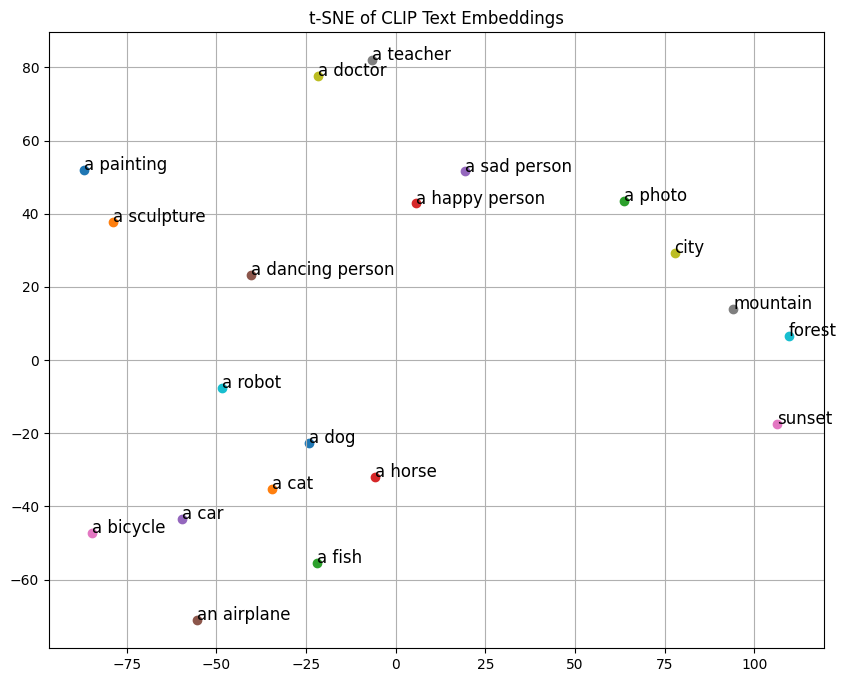

In [12]:
plt.figure(figsize=(10, 8))
for i, label in enumerate(prompts):
    x, y = text_embeddings_2d[i]
    plt.scatter(x, y)
    plt.annotate(label, (x, y), fontsize=12)
plt.title("t-SNE of CLIP Text Embeddings")
plt.grid(True)
plt.show()


In [13]:
import torch
import clip
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os


In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)


In [15]:
# Example: list of image paths (you can upload your own)
image_paths = [
    "/content/image1.jpg",
    "/content/image2.jpeg",
    "/content/image3.jpeg"
]

# Load and preprocess
images = [preprocess(Image.open(p)).unsqueeze(0).to(device) for p in image_paths]
image_input = torch.cat(images, dim=0)


In [16]:
text_prompts = [
    "A sunny beach",
    "A futuristic city",
    "A futuristic town",
    "A delicious pizza",
    "We want to reduce them to 2D to plot and visualize them"
]

text_tokens = clip.tokenize(text_prompts).to(device)


In [17]:
text_tokens

tensor([[49406,   320,  5438,  2117, 49407,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0],
        [49406,   320, 30987,  1305, 49407,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0, 

In [18]:
# Encode images and text
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_tokens)

# Normalize embeddings
image_features /= image_features.norm(dim=-1, keepdim=True)
text_features /= text_features.norm(dim=-1, keepdim=True)

# Compute cosine similarity
similarity = (100.0 * image_features @ text_features.T).softmax(dim=1)


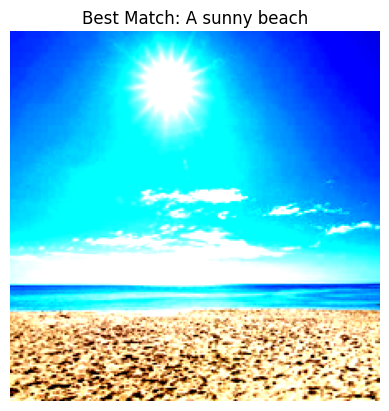

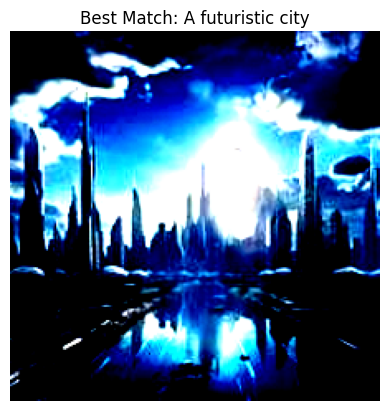

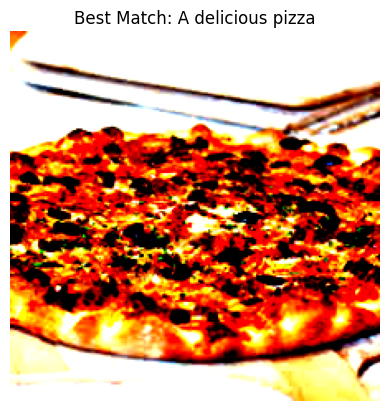

In [19]:
# Display each image with the best-matching text
for i, (image_tensor, scores) in enumerate(zip(image_input, similarity)):
    best_prompt_idx = scores.argmax().item()
    best_prompt = text_prompts[best_prompt_idx]

    plt.imshow(image_tensor.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    plt.title(f"Best Match: {best_prompt}")
    plt.show()


In [20]:
import torch
import clip
from PIL import Image

# Load the model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# Load your image
image_path = "/content/image4.jpeg"
image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)

# Define candidate text prompts
text_prompts = [
    "A pizza on a beach",
    "A cat on a couch",
    "A sunset over the ocean",
    "A person surfing",
    "A pepperoni pizza",
    "A tropical beach",
    "A dog playing in the sand"
]

# Tokenize text
text_tokens = clip.tokenize(text_prompts).to(device)

# Encode image and text
with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text_tokens)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Compute similarity
    similarity = (100.0 * image_features @ text_features.T).squeeze()

# 🔍 Display similarity results
print("🔍 Similarity Scores:")
for i, prompt in enumerate(text_prompts):
    print(f"{prompt:<30} : {similarity[i]:.2f}")


🔍 Similarity Scores:
A pizza on a beach             : 33.59
A cat on a couch               : 11.05
A sunset over the ocean        : 17.64
A person surfing               : 18.70
A pepperoni pizza              : 23.53
A tropical beach               : 20.38
A dog playing in the sand      : 16.38
